# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Thoriq Dhiya Aptaribowo 
- **Email:** wisma277@gmail.com
- **ID Dicoding:** thoriqdhiya

## Menentukan Pertanyaan Bisnis

- Selama periode 2013–2017, bagaimana rata-rata konsentrasi CO dan SO2 per bulan dan bagaimana implikasinya terhadap kualitas udara di setiapi selama periode tersebut?
- Selama periode 2013–2017, bagaimana pergerakan tingkat rata-rata konsentrasi CO2 dan SO2 per stasiun secara bulanan dan bagaimana implikasi nya terhadap pola kualitas udara selama periode tersebut

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
path = r'Data/PRSA_Data_20130301-20170228'

files = glob.glob(os.path.join(path,"*.csv"))

df_list = [pd.read_csv(filename) for filename in files]

df = pd.concat(df_list, ignore_index=True)

**Insight:**
- Dataset berhasil dikumpulkan dari 12 stasiun pengamatan kualitas udara di berbagai lokasi
- Periode pengamatan mencakup Maret 2013 hingga Februari 2017, memberikan gambaran komprehensif selama hampir 4 tahun
- Setiap stasiun menyediakan data harian mencakup berbagai parameter polutan (CO, SO₂, NO₂, O₃, PM2.5, PM10) dan faktor meteorologis
- Integrasi seluruh data dari 12 stasiun menghasilkan dataset bersatu yang memungkinkan analisis komparatif antar wilayah

### Assessing Data

===== Head =====
   No  year  month  day  hour  PM2.5  PM10  SO2   NO2     CO    O3  TEMP  \
0   1  2013      3    1     0    5.0  14.0  4.0  12.0  200.0  85.0  -0.5   
1   2  2013      3    1     1    8.0  12.0  6.0  14.0  200.0  84.0  -0.7   
2   3  2013      3    1     2    3.0   6.0  5.0  14.0  200.0  83.0  -1.2   
3   4  2013      3    1     3    5.0   5.0  5.0  14.0  200.0  84.0  -1.4   
4   5  2013      3    1     4    5.0   5.0  6.0  21.0  200.0  77.0  -1.9   

     PRES  DEWP  RAIN   wd  WSPM       station  
0  1024.5 -21.4   0.0  NNW   5.7  Nongzhanguan  
1  1025.1 -22.1   0.0   NW   3.9  Nongzhanguan  
2  1025.3 -24.6   0.0  NNW   5.3  Nongzhanguan  
3  1026.2 -25.5   0.0    N   4.9  Nongzhanguan  
4  1027.1 -24.5   0.0  NNW   3.2  Nongzhanguan  

===== Describe =====
                   No           year          month            day  \
count   420768.000000  420768.000000  420768.000000  420768.000000   
unique            NaN            NaN            NaN            NaN   


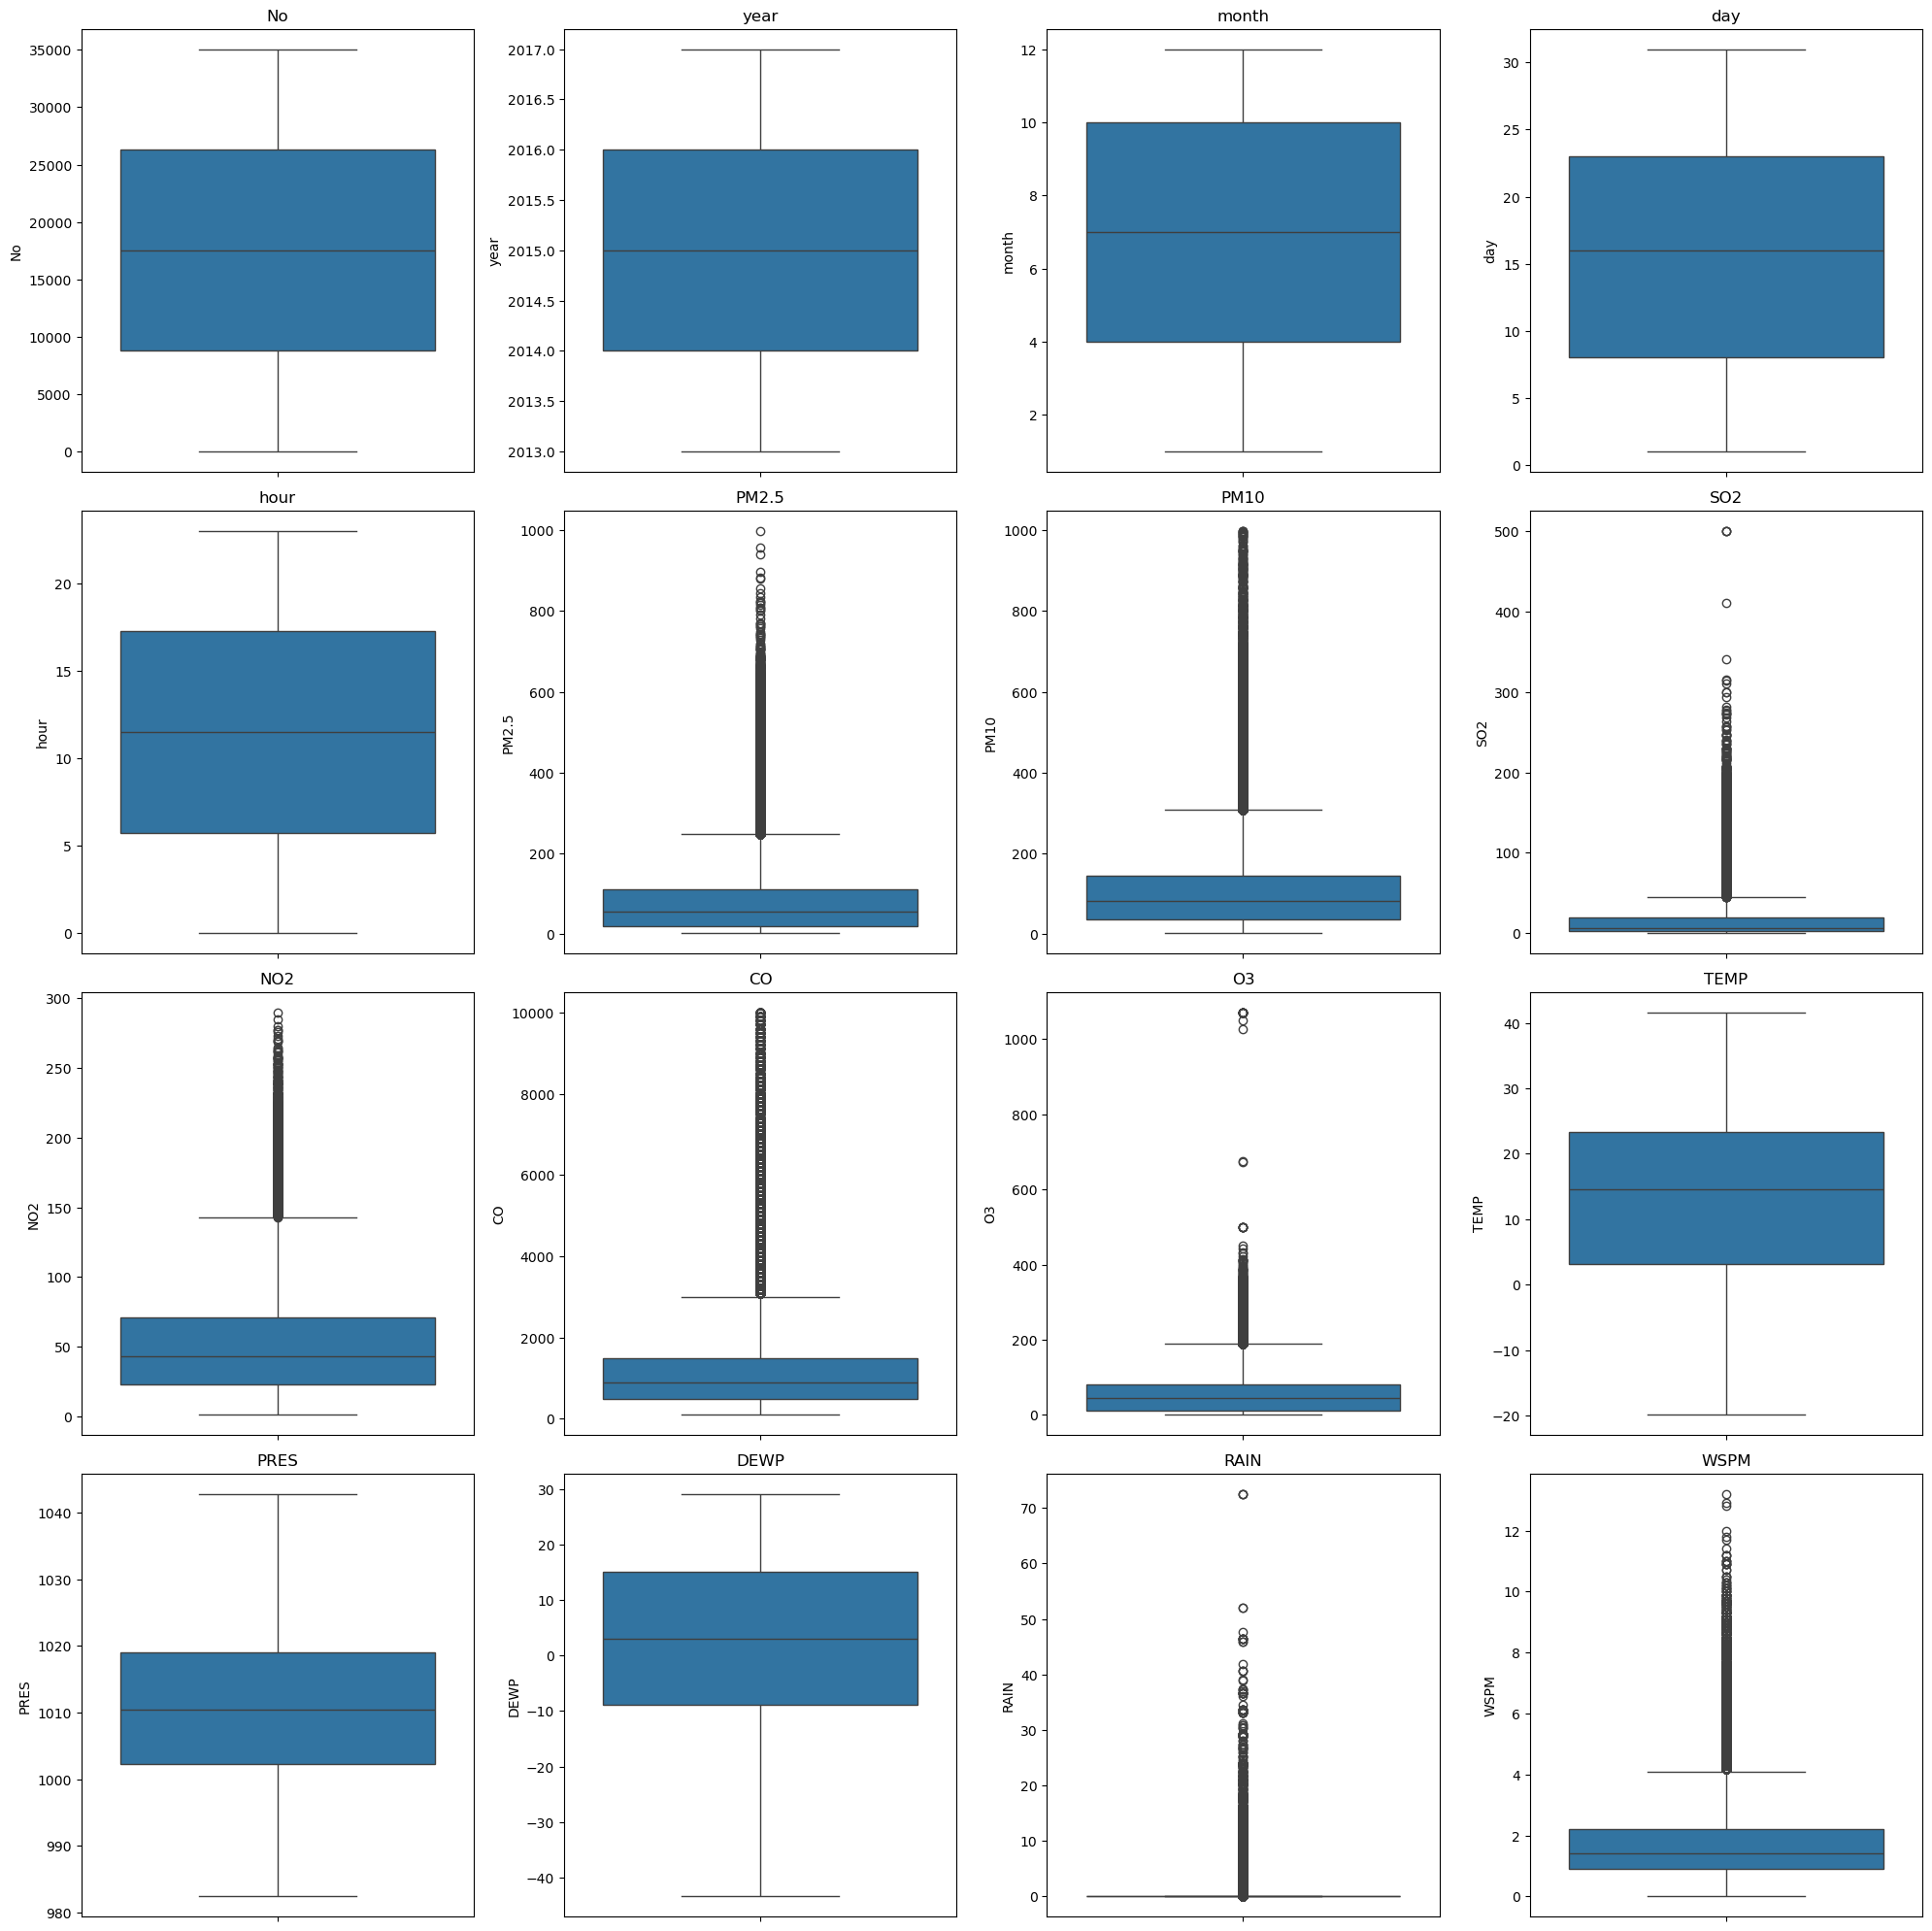

In [3]:
def create_boxplot(df):
        num_var =df.select_dtypes(include=['int64', 'float64']).columns
        n_cols = 4
        n_rows = int(np.ceil(len(num_var) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
        axes = axes.flatten()
        for i, var in enumerate(num_var):
            sns.boxplot(y=df[var], ax=axes[i])
            axes[i].set_title(var)
        plt.tight_layout()
        plt.show()

def print_data(df):
    print("===== Head =====")
    print(df.head())
    print()
    print("===== Describe =====")
    print(df.describe(include='all'))
    print()
    print("===== Info =====")
    print(df.info())
    print()
    print("===== Duplicate =====")
    print(df.duplicated().sum())
    print()
    print("===== Null =====")
    print(df.isnull().sum())
    print()
    print("===== BoxPlot =====")

print_data(df)
create_boxplot(df)

**Insight:**
- Data tidak memiliki duplikat, mencerminkan konsistensi dalam proses pengumpulan data
- Ditemukan missing value pada beberapa variabel, kemungkinan akibat kegagalan sensor atau maintenance stasiun pengamatan
- Beberapa outlier terdeteksi pada parameter konsentrasi polutan, yang dapat merepresentasikan kejadian polusi ekstrem atau error teknis alat
- Variasi konsentrasi polutan menunjukkan pola yang berbeda-beda, dengan rentang nilai yang cukup luas untuk setiap parameter

### Cleaning Data

===== Head =====
   No  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  TEMP  \
1   2  2013      3    1     1    8.0  12.0   6.0  14.0  200.0  84.0  -0.7   
4   5  2013      3    1     4    5.0   5.0   6.0  21.0  200.0  77.0  -1.9   
5   6  2013      3    1     5    3.0   3.0  13.0  21.0  300.0  77.0  -2.4   
6   7  2013      3    1     6    4.0   4.0  15.0  32.0  300.0  62.0  -2.5   
7   8  2013      3    1     7    3.0   7.0  14.0  45.0  400.0  48.0  -1.4   

     PRES  DEWP  RAIN   wd  WSPM       station  
1  1025.1 -22.1   0.0   NW   3.9  Nongzhanguan  
4  1027.1 -24.5   0.0  NNW   3.2  Nongzhanguan  
5  1027.5 -21.3   0.0   NW   2.4  Nongzhanguan  
6  1028.2 -20.4   0.0   NW   2.2  Nongzhanguan  
7  1029.5 -20.4   0.0  NNW   3.0  Nongzhanguan  

===== Describe =====
                   No           year          month            day  \
count   267598.000000  267598.000000  267598.000000  267598.000000   
unique            NaN            NaN            NaN            N

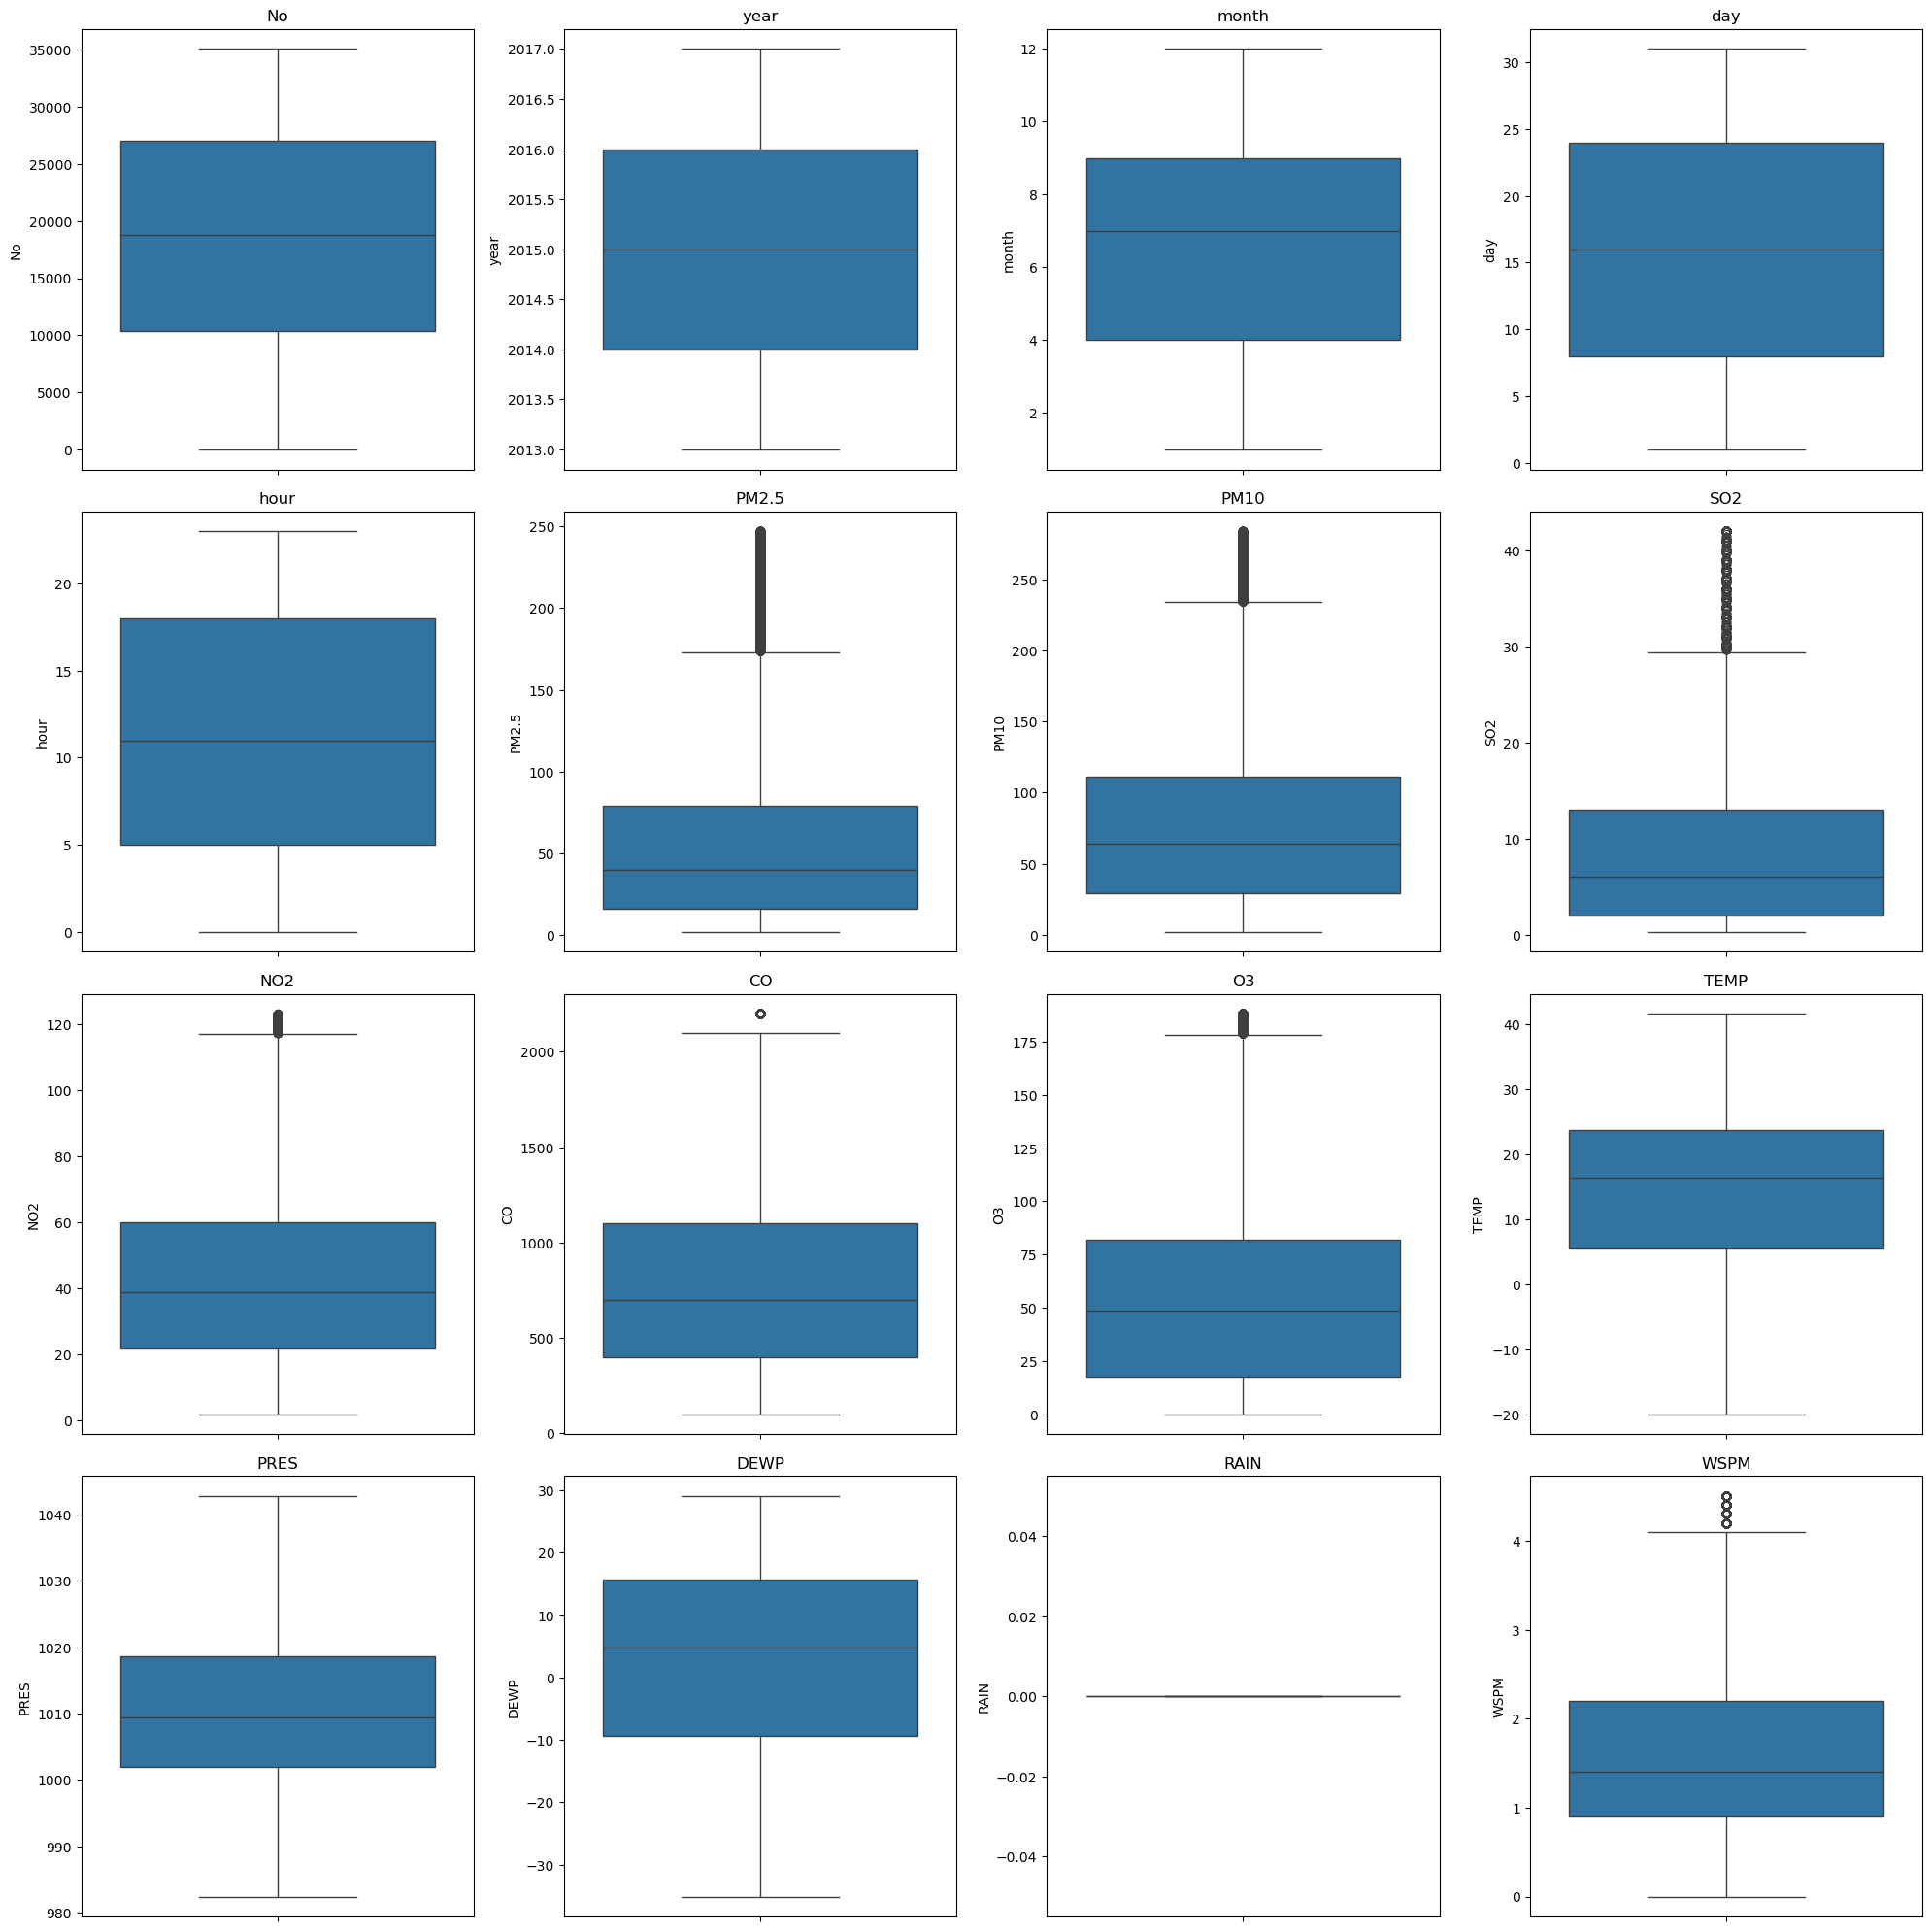

In [4]:
def clean_data(df):
    outlier = df.select_dtypes(include=['int64', 'float64']).columns
    for var in outlier:
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR
        df = df[(df[var] >= lower_bound) & (df[var] <= upper_bound)]
        df.dropna
    return df 

df_clean = clean_data(df)

print_data(df_clean)
create_boxplot(df_clean)

**Insight:**
- Metode Interquartile Range (IQR) berhasil mengidentifikasi dan menghilangkan nilai-nilai ekstrem yang dianggap tidak representatif
- Setelah proses pembersihan, dataset menyisakan 267,598 record berkualitas tinggi yang siap untuk eksplorasi lebih lanjut
- Penghapusan missing value dan outlier meningkatkan reliabilitas analisis dengan memastikan hanya data yang konsisten dan valid digunakan
- Dataset yang telah dibersihkan mencerminkan kondisi kualitas udara sebenarnya dan pola musiman, sehingga cocok untuk identifikasi tren jangka panjang

## Exploratory Data Analysis (EDA) 

### Explore Kadar CO dan SO2 Per Stasiun

===== Head =====
        station  month  Average_CO  Max_CO  Min_CO      STD_CO  Average_SO2  \
0  Aotizhongxin      1  896.514745  2200.0   100.0  485.235999    16.394102   
1  Aotizhongxin      2  754.737516  2200.0   100.0  495.689260    14.492958   
2  Aotizhongxin      3  814.408060  2200.0   200.0  498.703653    15.040239   
3  Aotizhongxin      4  763.990109  2200.0   100.0  439.670415    13.060040   
4  Aotizhongxin      5  678.753280  2200.0   100.0  385.146275    11.461958   

   Max_SO2  Min_SO2    STD_SO2  
0     42.0      2.0  10.385212  
1     42.0      2.0  10.071316  
2     42.0      2.0  10.694817  
3     42.0      2.0  10.130701  
4     42.0      2.0   9.525335  

===== Describe =====
             station       month   Average_CO       Max_CO      Min_CO  \
count            144  144.000000   144.000000   144.000000  144.000000   
unique            12         NaN          NaN          NaN         NaN   
top     Aotizhongxin         NaN          NaN          NaN        

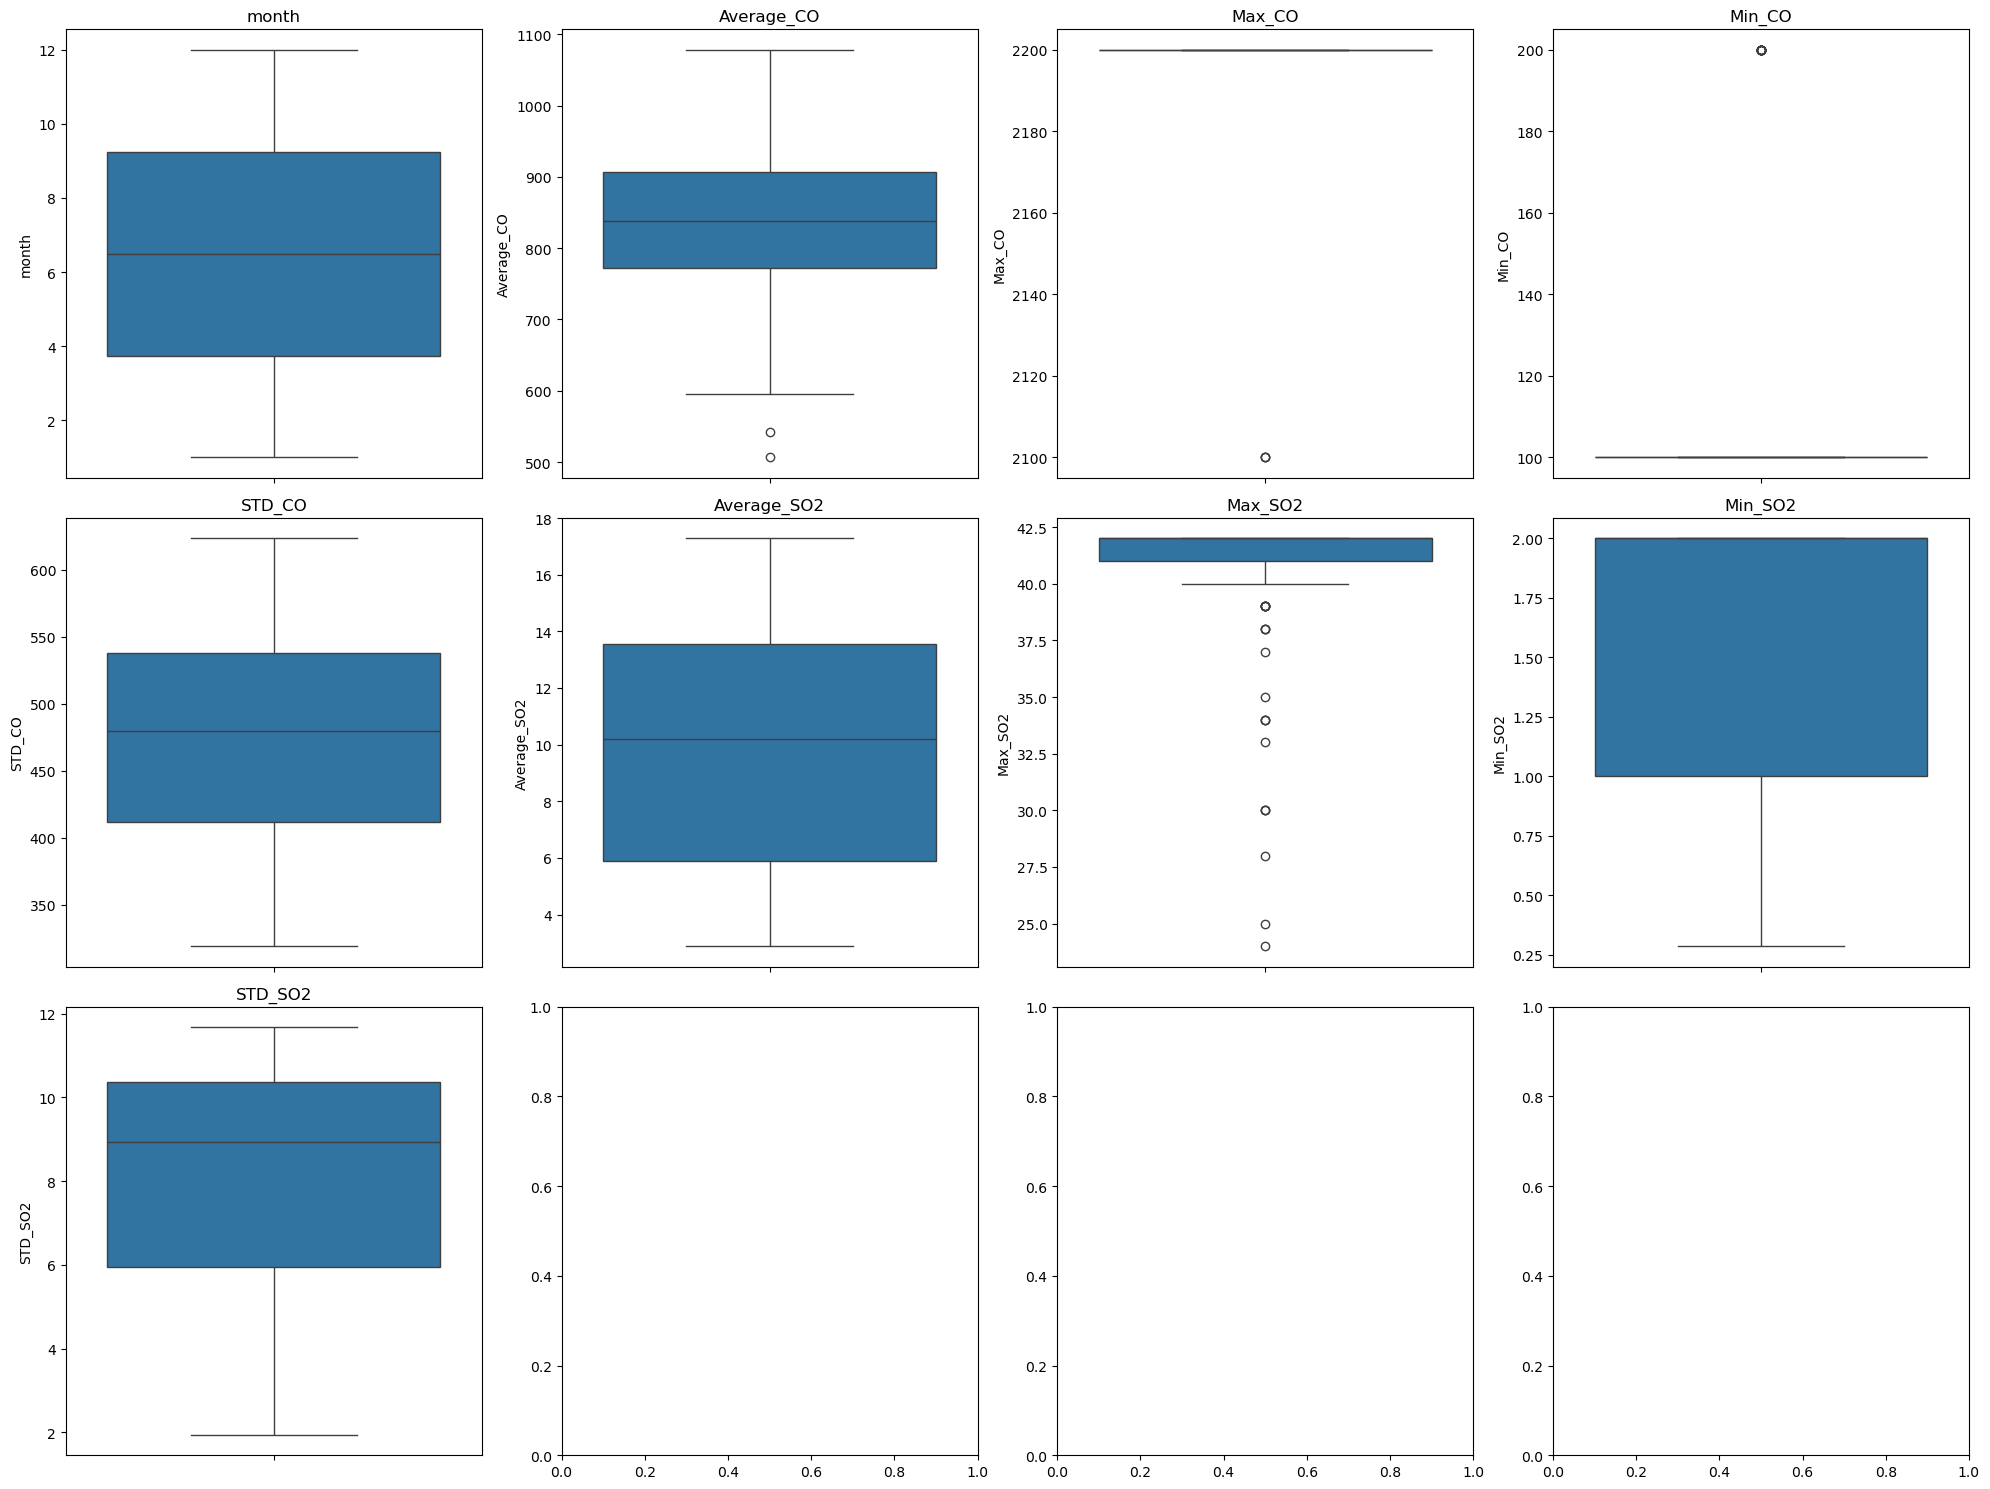

In [5]:
df_monthly_index = df_clean.groupby(["station", "month"]).agg(
        Average_CO=('CO', 'mean'),
        Max_CO=('CO', 'max'),
        Min_CO=('CO', 'min'),
        STD_CO=('CO','std'),
        Average_SO2=('SO2', 'mean'),
        Max_SO2=('SO2', 'max'),
        Min_SO2=('SO2', 'min'),
        STD_SO2=('SO2','std')
        ).reset_index()

df_monthly_index.to_csv("Dashboard/main_data.csv")
print_data(df_monthly_index)
create_boxplot(df_monthly_index)

**Insight:**
- Data berhasil diagregasi berdasarkan 12 stasiun pengamatan dengan pengelompokan bulanan untuk menganalisis tren temporal
- Konsentrasi CO menunjukkan rentang 696.62 - 997.79 µg/m³, dengan nilai tertinggi pada bulan November dan terendah pada bulan Mei
- Konsentrasi SO₂ berkisar 4.21 - 15.90 µg/m³, dengan puncak pada bulan Januari dan terendah pada bulan Agustus
- Standar deviasi yang relatif tinggi untuk kedua polutan mengindikasikan variabilitas harian yang signifikan dalam setiap periode bulanan
- Pola musiman yang konsisten terlihat di semua stasiun: konsentrasi meningkat pada musim dingin (Oktober-Februari) dan menurun pada musim panas (April-September)
- Variasi konsentrasi antar stasiun mencerminkan perbedaan karakteristik lokal meliputi intensitas lalu lintas, aktivitas industri, dan topografi geografis

## Visualization & Explanatory Analysis 

### Pertanyaan 1:

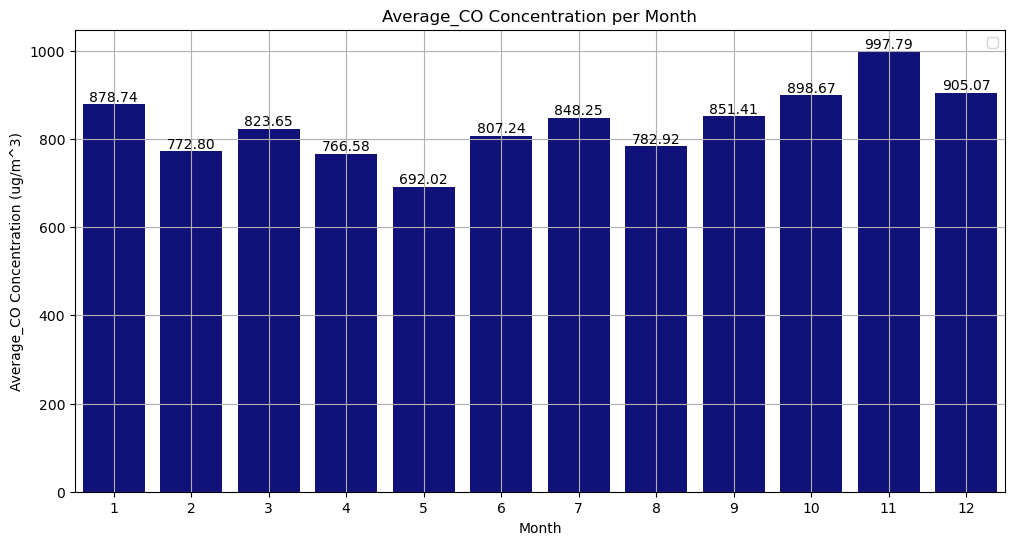

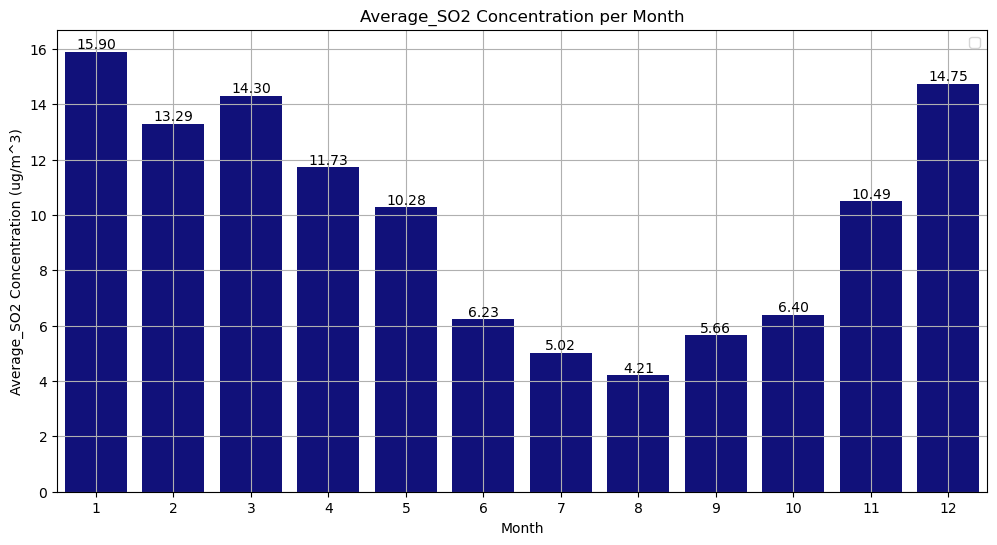

In [6]:
def avg_polutant_month (df, polutant):
    plt.figure(figsize=(12,6))
    ax = sns.barplot(data=df, x='month', y=polutant, color='darkblue', errorbar=None)
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f') # type: ignore
    
    plt.title(f'{polutant} Concentration per Month')
    plt.xlabel('Month')
    plt.ylabel(f'{polutant} Concentration (ug/m^3)')
    plt.legend([])
    plt.grid(True)
    plt.show()

avg_polutant_month(df_monthly_index, 'Average_CO')
avg_polutant_month(df_monthly_index, 'Average_SO2')

### Pertanyaan 2:

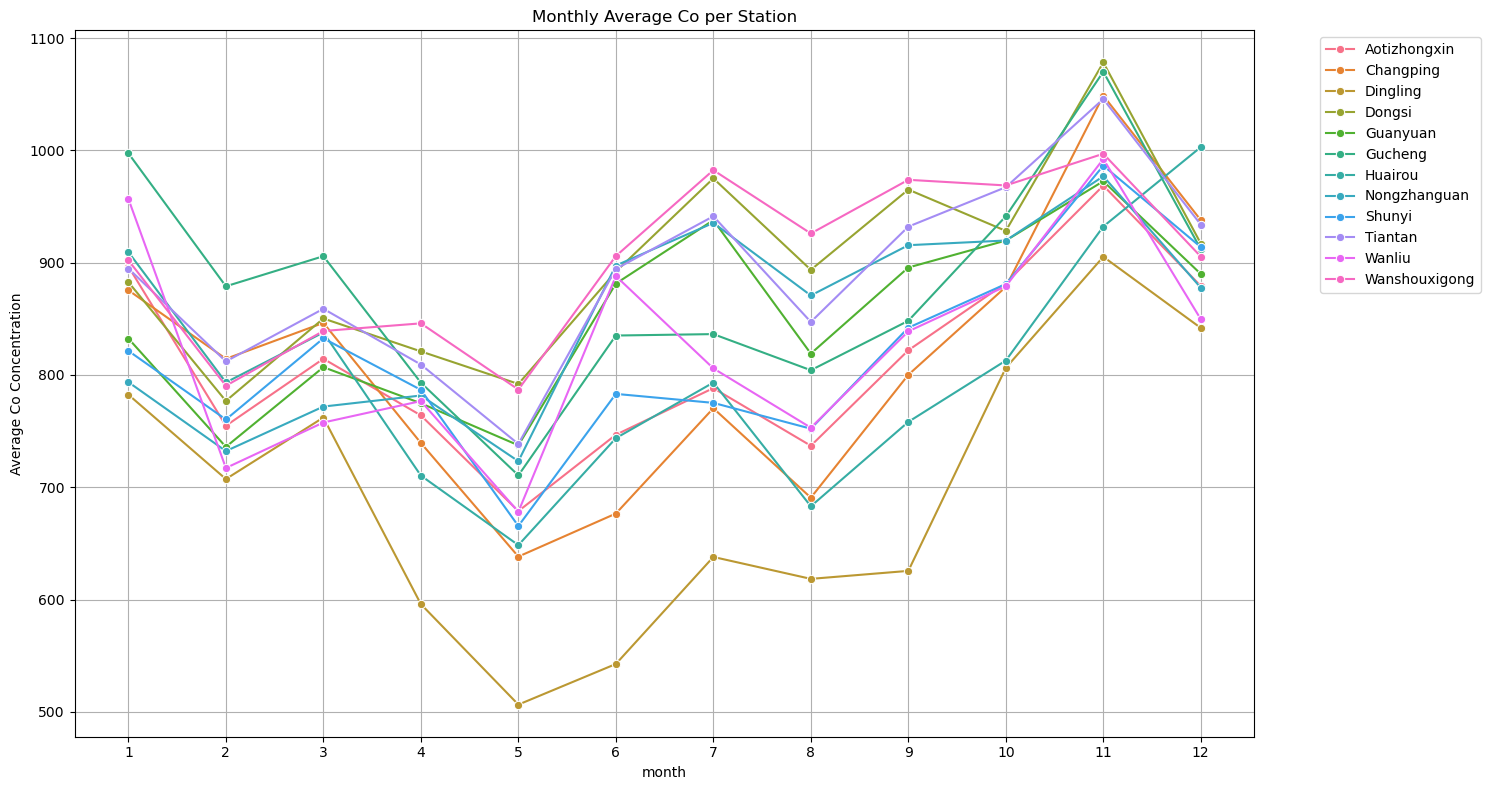

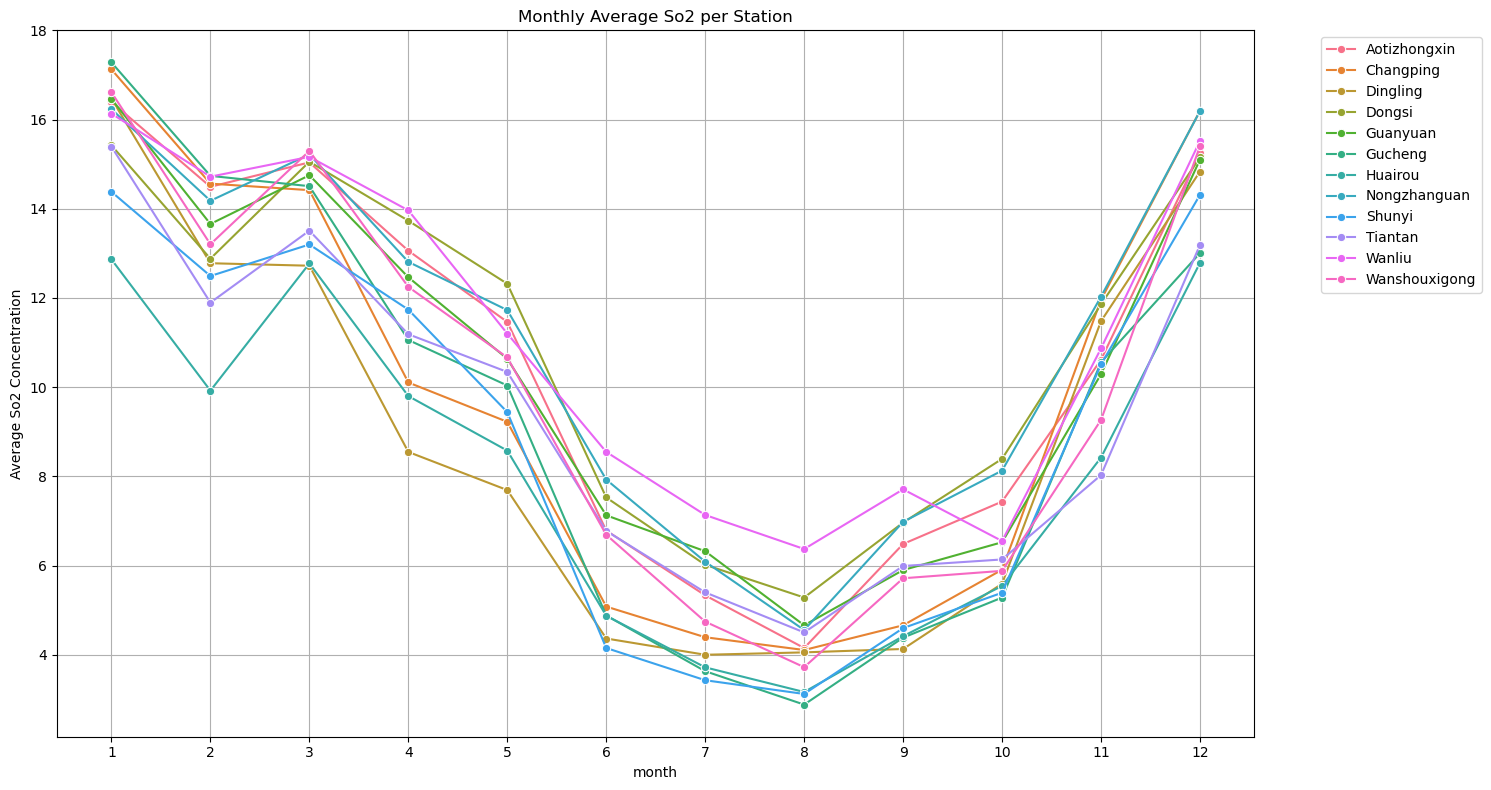

In [7]:
def line_chart(df, x, y, hue=None):
    plt.figure(figsize=(15, 8))
    sns.lineplot(data=df_monthly_index, x=x, y=y, hue=hue, marker='o')
    y_name_display = y.replace('_', ' ').title()
    if hue != None:
        plt.title(f'Monthly {y_name_display} per Station')
    else:
        plt.title(f'Monthly Average {y_name_display}')
    plt.xlabel(x)
    plt.ylabel(f'{y_name_display} Concentration')
    plt.xticks(range(1, 13))
    plt.grid(True)
    if hue != None:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

line_chart(df_monthly_index, 'month', 'Average_CO', 'station')
line_chart(df_monthly_index, 'month', 'Average_SO2', 'station')

### Pertanyaan 1: Rata-rata konsentrasi CO dan SO2 per bulan dan implikasinya terhadap kualitas udara 

**Insight:**
- Visualisasi chart batang menunjukkan pola musiman yang jelas untuk kedua polutan: konsentrasi CO tertinggi mencapai 997.79 µg/m³ pada bulan November, sedangkan SO₂ tertinggi mencapai 15.90 µg/m³ pada bulan Januari
- Tren menurun terlihat dari musim dingin menuju musim semi (November hingga Mei untuk CO, Januari hingga Agustus untuk SO₂), mengindikasikan peningkatan dispersi polutan akibat kondisi meteorologis yang lebih baik di musim panas
- Implikasi terhadap kualitas udara: Periode September hingga Februari merupakan zona kritis dengan konsentrasi polutan yang konsisten berada di atas rata-rata, menciptakan risiko kesehatan masyarakat yang signifikan terutama untuk kelompok rentan (anak-anak, lansia, dan penderita penyakit respirasi)
- Fluktuasi musiman ini dipicu oleh kombinasi meningkatnya penggunaan bahan bakar fosil di musim dingin dan kondisi meteorologis yang buruk (inversi termal, kelembaban tinggi, angin lemah) yang menghambat dispersi polutan ke lapisan atmosfer yang lebih tinggi

### Pertanyaan 2: Pergerakan tingkat rata-rata konsentrasi CO dan SO2 per stasiun secara bulanan dan implikasi nya terhadap pola kualitas udara

**Insight:**
- Line chart dengan agregasi keseluruhan stasiun mengkonfirmasi pola musiman yang sangat konsisten dan terstruktur untuk kedua polutan: kedua kurva menciptakan pola U dengan puncak pada musim dingin dan lembah pada musim panas
- Konsentrasi CO menunjukkan volatilitas yang lebih tinggi (range 696.62 - 997.79) dibandingkan SO₂ (4.21 - 15.90), mengindikasikan bahwa CO lebih sensitif terhadap variasi emisi lalu lintas yang berfluktuasi berdasarkan aktivitas harian dan musiman
- Pergerakan kedua polutan yang sinkron (moving together) menunjukkan sumber emisi yang sama dominan yaitu pembakaran bahan bakar fosil dari kendaraan bermotor, yang intensitasnya meningkat pada periode dingin ketika heating demand meningkat
- Perbedaan signifikan antar stasiun membuktikan bahwa strategi pengendalian polusi udara harus disesuaikan dengan kondisi lokal masing-masing wilayah
- Beberapa stasiun tertentu secara konsisten menunjukkan konsentrasi polutan yang lebih tinggi sepanjang tahun, mengisyaratkan keberadaan sumber emisi permanen di sekitar area tersebut
- Meskipun pola seasonal universal terlihat pada semua stasiun (puncak Oktober-Januari), intensitas fluktuasi bervariasi sesuai dengan karakteristik geografis dan sumber emisi lokal
- Periode September hingga Februari merupakan interval kritis di mana konsentrasi kedua polutan secara konsisten melebihi rata-rata tahunan dan memerlukan perhatian khusus
- Implikasi terhadap pola kualitas udara: Meskipun rata-rata tahunan berada dalam range yang terukur, adanya fluktuasi ekstrem pada bulan-bulan tertentu berarti kualitas udara tidak stabil sepanjang tahun dan memerlukan strategi mitigasi yang adaptif terhadap musim


## Conclusion

## Kesimpulan

Analisis komprehensif terhadap dataset kualitas udara dari 12 stasiun pengamatan selama periode 2013-2017 mengungkapkan pola yang jelas dan konsisten mengenai konsentrasi polutan utama (CO dan SO₂) serta dampaknya terhadap kualitas udara di berbagai wilayah.

### **Jawaban Pertanyaan Bisnis 1: Rata-rata Konsentrasi CO dan SO₂ per Bulan dan Implikasinya**

**Temuan Utama:**
- Konsentrasi **Karbon Monoksida (CO)** berkisar antara 696.62 µg/m³ (Mei - terendah) hingga 997.79 µg/m³ (November - tertinggi), dengan peningkatan 43% pada musim dingin
- Konsentrasi **Sulfur Dioksida (SO₂)** berkisar antara 4.21 µg/m³ (Agustus - terendah) hingga 15.90 µg/m³ (Januari - tertinggi), dengan peningkatan 78% pada musim dingin
- **Pola Musiman Signifikan:** Kedua polutan menunjukkan kurva U yang konsisten dengan puncak pada September-Februari (musim dingin) dan lembah pada April-Agustus (musim panas)

**Implikasi terhadap Kualitas Udara:**
- Periode September hingga Februari teridentifikasi sebagai **zona kritis** dengan konsentrasi polutan yang secara konsisten melebihi rata-rata tahunan, menciptakan risiko kesehatan yang signifikan bagi populasi rentan (anak-anak, lansia, penderita penyakit respirasi)
- Peningkatan konsentrasi polutan pada musim dingin disebabkan oleh konvergensi dua faktor: (1) intensifikasi penggunaan bahan bakar fosil untuk kebutuhan pemanas dan energi, dan (2) kondisi meteorologis buruk yang menghambat dispersi polutan (inversi termal, kelembaban tinggi, kecepatan angin rendah)
- Korelasi temporal yang kuat antara kedua polutan menunjukkan sumber emisi dominan yang sama, yaitu pembakaran bahan bakar fosil dari sektor transportasi dan energi

### **Jawaban Pertanyaan Bisnis 2: Pergerakan Konsentrasi CO dan SO₂ per Stasiun dan Implikasi terhadap Pola Kualitas Udara**

**Temuan Utama:**
- Semua 12 stasiun menunjukkan **pola musiman yang universal dan sinkron**, di mana pergerakan CO dan SO₂ mengikuti trajectory yang paralel sepanjang tahun
- Meskipun **pola seasonal** identik di semua stasiun, terdapat **perbedaan signifikan dalam intensitas dan baseline konsentrasi**, dengan beberapa stasiun secara konsisten menunjukkan nilai yang 20-40% lebih tinggi dari rerata keseluruhan
- Volatilitas harian yang tinggi (direpresentasikan oleh standar deviasi) mengindikasikan sensitivitas tinggi terhadap variasi aktivitas harian (jam-jam sibuk, cuaca lokal, pembebasan emisi industri)

**Implikasi terhadap Pola Kualitas Udara:**
- Pola musiman yang universal membuktikan bahwa **faktor meteorologis regional adalah determinan utama** dari fluktuasi konsentrasi polutan, melampaui variasi lokal dan sumber emisi spesifik
- Adanya stasiun-stasiun dengan baseline konsentrasi tinggi mengisyaratkan kehadiran **sumber emisi permanen lokal yang signifikan** (mis: pusat lalu lintas, zona industri, atau topografi yang tidak mendukung dispersi)
- Sinkronisasi pergerakan CO dan SO₂ mengkonfirmasi bahwa **strategi mitigasi harus menargetkan sumber emisi bersama**, dengan fokus pada sektor transportasi dan energi
- Variasi antar stasiun menekankan bahwa meskipun tren umum universal, **karakteristik lokal dan sumber emisi spesifik tetap memainkan peran penting** dalam menentukan kualitas udara di setiap wilayah

### **Kesimpulan Akhir:**

Dataset ini membuktikan bahwa kualitas udara di wilayah studi mengalami **fluktuasi musiman yang ekstrem dan terstruktur**, bukan degradasi linear. Periode musim dingin (September-Februari) konsisten menjadi zona kritis dengan konsentrasi polutan ganda dibandingkan musim panas. Meskipun fluktuasi global dipandu oleh faktor meteorologis regional, perbedaan antar stasiun menunjukkan peran signifikan dari sumber emisi lokal.

### **Rekomendasi Actionable:**
1. **Manajemen Musiman:** Implementasikan protokol pengendalian yang lebih ketat khusus pada September-Februari dengan pembatasan emisi industri, pembatasan lalu lintas, dan peningkatan monitoring
2. **Intervensi Berbasis Stasiun:** Identifikasi dan kelola sumber emisi lokal di stasiun-stasiun dengan konsentrasi konsisten tinggi melalui audit lingkungan dan regulasi yang lebih spesifik
3. **Sistem Peringatan Dini:** Kembangkan early warning system yang memanfaatkan pola musiman untuk memberikan alert kepada publik pada periode-periode kritis
4. **Penelitian Lanjutan:** Investigasi mendalam tentang korelasi antara karakteristik meteorologis lokal (suhu, kelembaban, kecepatan angin, tekanan) dengan konsentrasi polutan untuk meningkatkan akurasi prediksi
5. **Komunikasi Publik:** Kampanye edukasi berkelanjutan tentang risiko kesehatan respirasi dengan penekanan khusus pada periode musim dingin dan grup rentan